In [1]:
import random
from pathlib import Path
from collections import defaultdict
import itertools as it

import pandas as pd
import numpy as np

from IPython.display import display
import matplotlib as mpl
import matplotlib.dates as mpl_dates
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from conjugate_normal import conjugate_normal

In [2]:
paths = list(Path("../data/summaries").glob("*.csv"))
df = (
    pd
    .concat(
        [pd.read_csv(path) for path in paths],
        keys = [path.stem for path in paths]
    )[[
        "id",
        "page_slug",
        "user_id",
        "text",
        "isPassed",
        "containment_score",
        "similarity_score",
        "wording_score",
        "content_score",
        "created_at",
    ]]
    .drop_duplicates(subset=['text'])
    .dropna(subset=['content_score', 'page_slug'])
    .sort_values(by=["created_at"])
)
# Convert to datetime if not already done
df['created_at'] = pd.to_datetime(df['created_at'], format="mixed", utc=True)
df = df.sort_values('created_at')

first_submissions = df.drop_duplicates(subset=["user_id", "page_slug"])

In [3]:
df.sample(3)

id  \
business-law    220  666b63b8-7a1e-4dfe-a611-7a36749b2746   
                655  55ecb547-0ea2-44d4-804c-6993a69de577   
intro-computing 269  6af7e875-62ce-465b-b94c-5d3d26b39e78   

                                        page_slug                    user_id  \
business-law    220  the-pretrial-and-trial-phase  clr5b30zq0000l80fkile7ubi   
                655      schools-of-legal-thought  clre9gvct0000l20fxio85n5n   
intro-computing 269                         loops  clt3f7sdq0000lwpgyt0h6n4s   

                                                                  text  \
business-law    220  During the discovery process, depending on the...   
                655  In this section of the textbook, I read about ...   
intro-computing 269  Broadly, this section dealt with loops in Pyth...   

                    isPassed  containment_score  similarity_score  \
business-law    220     True             0.4537          0.623332   
                655    False             0.1368          0.713305   
intro-computing 269     True             0.1389          0.854211   

                     wording_score  content_score  \
business-law    220      -0.089164       0.283423   
                655      -0.214382      -0.638992   
intro-computing 269       0.124111      -0.322921   

                                          created_at  
business-law    220 2024-01-11 04:25:16.035000+00:00  
                655 2024-01-15 02:29:23.424000+00:00  
intro-computing 269 2024-02-26 21:36:43.142000+00:00

## Score Distributions

What does the distribution of scores look like by volume?

In [4]:
display(df.agg({
    "containment_score": ["count", "mean", "std"],
    "similarity_score": ["count", "mean", "std"],
    "wording_score": ["count", "mean", "std"],
    "content_score": ["count", "mean", "std"],
    })
)

display(df.groupby(level=0).agg({
    # "containment_score": ["count", "mean", "std"],
    # "similarity_score": ["mean", "std"],
    # "wording_score": ["mean", "std"],
    "content_score": ["count", "mean", "std", ("20%", lambda x : np.quantile(x, q=0.20))],
    })
)

display(first_submissions.groupby(level=0).agg({
    "content_score": ["count", "mean", "std", ("20%", lambda x : np.quantile(x, q=0.20))],
    })
)

,containment_score,similarity_score,wording_score,content_score
count,3508.000000,3508.000000,1766.000000,3508.000000
mean,0.082879,0.730115,0.247556,0.098162
std,0.211388,0.324206,0.479839,0.606555


content_score                              
                           count      mean       std       20%
business-law                 932 -0.242927  0.725733 -1.000000
intro-computing              460  0.010441  0.380371 -0.313237
intro-computing-2            624  0.351795  0.177278  0.192964
learning-analytics           374  0.665977  0.339527  0.425964
poe                         1118  0.087086  0.596986 -0.313268

content_score                              
                           count      mean       std       20%
business-law                 688 -0.174132  0.775031 -1.000000
intro-computing              419  0.044310  0.362906 -0.248613
intro-computing-2            556  0.372892  0.171829  0.216671
learning-analytics           339  0.684393  0.326035  0.475321
poe                          943  0.105934  0.612369 -0.306858

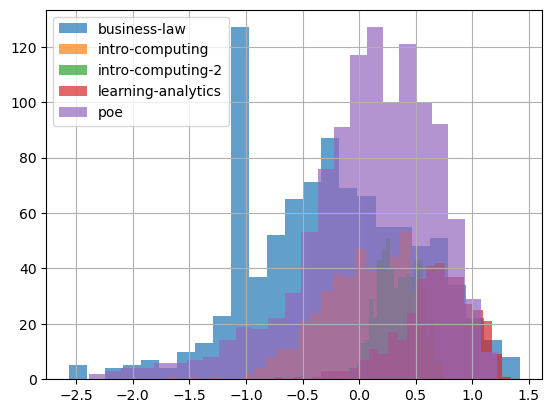

In [5]:
df["content_score"].groupby(level=0).hist(legend=True, bins=25, alpha=0.7);

## Simulating the Bayesian Score Distributions

If we had used a Bayesian approach to estimate the scoring distribution over time during these deployments...

In [6]:
def simulate_thresholds(df, hp_dict):
    """
    Simulate thresholds using Bayesian updating for volumes and students.
    
    Args:
        df: DataFrame with columns including content_score, user_id, and a MultiIndex
        hp_dict: Dictionary containing hyperparameters
    
    Returns:
        tuple: (updated_df, submission_threshold_df, volumes, students, student_success, volume_updates, student_updates)
    """
    # Prior Paramaters
    mu_global = hp_dict['mu_global']
    k_global = hp_dict['k_global']
    alpha_global = hp_dict['alpha_global']
    beta_global = hp_dict['beta_global']
    target_percentile = hp_dict['target_percentile']

    # Forgetting
    max_k = hp_dict['max_k']
    max_alpha = hp_dict.get('max_alpha', None)
    k_decay = hp_dict.get('k_decay', None)
    alpha_decay = hp_dict['alpha_decay']
    beta_decay = hp_dict['beta_decay']

    # Student Parameters
    k_volume = hp_dict['k_volume']
    student_variance_scale = hp_dict['student_variance_scale']
    student_max_k = hp_dict['student_max_k']
    student_k_decay = hp_dict['student_k_decay']
    student_alpha_decay = hp_dict['student_alpha_decay']
    student_beta_decay = hp_dict['student_beta_decay']

    # Initialize containers
    volumes = {}
    students = {}
    student_success = defaultdict(list)
    volume_updates = defaultdict(list)
    student_updates = defaultdict(list)
    submission_threshold = []
    
    # Calculate starting threshold
    start_threshold = conjugate_normal(
        mu_global, k_global, alpha_global, beta_global, 
        percentile=target_percentile
    ).threshold
    
    # Create a copy of df to avoid modifying the original
    df_copy = df.copy()
    
    for row in df_copy.itertuples():
        volume_name = row.Index[0]
        
        # Initialize volume if not exists
        if volume_name not in volumes:
            volumes[volume_name] = conjugate_normal(
                mu_global,
                k_global,
                alpha_global,
                beta_global,
                percentile=target_percentile,
                max_k=max_k,
                max_alpha=max_alpha,
                k_decay=k_decay,
                alpha_decay=alpha_decay,
                beta_decay=beta_decay,
            )
        volume = volumes[volume_name]
    
        # Create student prior from volume prior information
        student_dist = conjugate_normal(
            volume.mu,
            k_volume,
            volume.alpha,
            volume.beta * student_variance_scale,
            percentile=target_percentile,
            max_k=student_max_k,
            k_decay=student_k_decay,
            alpha_decay=student_alpha_decay,
            beta_decay=student_beta_decay,
        )
    
        # Update Volume Prior
        volume.update([row.content_score])
        volume_updates[volume_name].append((
            volume.mu, volume.sigma, volume.threshold, 
            volume.alpha, volume.beta, volume.k
        ))
    
        # Handle student threshold
        if row.user_id in students:
            score_history = students[row.user_id]
            student_dist.update(score_history)
            threshold = student_dist.threshold
        else:
            students[row.user_id] = []
            threshold = volume.threshold
    
        submission_threshold.append(threshold)
        student_success[(volume_name, row.user_id)].append(row.content_score > threshold)
    
        # Update student records
        student_updates[row.user_id].append((
            student_dist.mu, student_dist.sigma, 
            student_dist.threshold, row.content_score
        ))
        students[row.user_id].append(row.content_score)
    
    # Add threshold column to dataframe
    df_copy["bayesian_threshold"] = submission_threshold
    
    return (
        df_copy,
        start_threshold,
        student_success,
        volume_updates,
        student_updates
    )

In [9]:
def plot_thresholds(df, start_threshold, target_percentile, max_volumes=5, figsize=(20, 6)):
    """
    Plot content score personalized thresholds by volume.
    
    Args:
        df: DataFrame with columns including 'created_at', 'content_score', 'bayesian_threshold'
            and a volume index level
        start_threshold: Initial threshold value to plot as horizontal line
        target_percentile: Target percentile for calculating pass rate
        max_volumes: Maximum number of volumes to plot (default: 5)
        figsize: Figure size tuple (default: (20, 6))
        save_path: Optional path to save the figure (default: None)
    
    Returns:
        matplotlib.figure.Figure: The created figure object
    """
    # Create a copy to avoid modifying the original dataframe
    df_copy = df.copy()
    
    # Set style
    sns.set_style("whitegrid")
    
    # Get unique volumes and limit to max_volumes
    volume_groups = list(df_copy.reset_index(0, names="volume").groupby("volume"))
    num_volumes = min(len(volume_groups), max_volumes)
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, num_volumes, figsize=figsize, sharey=True)
    fig.suptitle('Content Score Personalized Thresholds by Volume', 
                 fontsize=16, y=1.02)
    
    # Handle case where there's only one volume (axes won't be a list)
    if num_volumes == 1:
        axes = [axes]
    
    # Plot each volume on its own subplot
    for i, (volume_name, group) in enumerate(volume_groups[:num_volumes]):
        ax = axes[i]
        
        # Create the main scatter plot
        sns.scatterplot(ax=ax, data=group, x='created_at', y='content_score', 
                       alpha=0.2, color='gray', s=5)
        
        # Calculate and plot rolling average (10 submissions)
        rolling_avg = group['content_score'].rolling(window=10, min_periods=1).mean()
        sns.lineplot(ax=ax, x=group["created_at"], y=rolling_avg, 
                     color='black', linewidth=.6, alpha=.6)
        
        # Draw Bayesian Threshold
        threshold_rolling = group["bayesian_threshold"].rolling(window=min(10, len(group)), min_periods=1).mean()
        sns.lineplot(ax=ax, x=group["created_at"], y=threshold_rolling, 
                     color='purple', linewidth=.6, alpha=0.6)
    
        # Draw starting threshold
        ax.axhline(y=start_threshold, color="purple", linestyle='--', linewidth=0.5, alpha=0.8)
    
        # Draw target pass rate
        target_pass_rate = 1 - target_percentile
        ax.axhline(y=target_pass_rate, color="red", linestyle='--', alpha=0.8)
        
        # Draw Pass Rate Rolling Window
        pass_rate_rolling = (group["content_score"] > group["bayesian_threshold"]).astype(int).rolling(
            window=min(50, len(group)), min_periods=1).mean()
        sns.lineplot(ax=ax, x=group["created_at"], y=pass_rate_rolling, 
                     color='red', linewidth=1.5, alpha=0.7)
        
        # Format each subplot
        ax.set_title(f'Volume: {volume_name}', fontweight='bold', pad=10)
        
        # Format x-axis to show dates nicely
        ax.xaxis.set_major_formatter(mpl_dates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mpl_dates.DayLocator(interval=max(1, len(group)//6)))
        ax.tick_params(axis='x', rotation=45)
        
        # Only show y-label on leftmost plot
        if i == 0:
            ax.set_ylabel('Content Score')
        else:
            ax.set_ylabel('')
        
        # Set x-label
        ax.set_xlabel('Date')
        
        # Add basic stats as text
        avg_score = group['content_score'].mean()
        pass_rate = (group["content_score"] > group["bayesian_threshold"]).mean()
        ax.text(0.02, 0.12, 
                f'Avg Content Score: {avg_score:.3f}\nPass Rate: {pass_rate:.1%}\nSubmissions: {len(group):,}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                fontsize=9)
    
    # Create a single legend for all subplots
    handles = [
        plt.Line2D([0], [0], marker='o', color='gray', alpha=0.4, linestyle='None', markersize=4, label='Raw Score'),
        plt.Line2D([0], [0], color='black', linewidth='.6', label='Content Score Rolling Avg (10th)'),
        plt.Line2D([0], [0], color='purple', linewidth=1, alpha=0.9, label='Bayesian Threshold Rolling Avg (10th)'),
        plt.Line2D([0], [0], color='purple', linewidth=0.5, linestyle='--', alpha=0.9, label='Starting Threshold (0.3)'),
        plt.Line2D([0], [0], color='red', linestyle='--', alpha=0.8, label=f'Target Pass Rate ({target_pass_rate:.2f})'),
        plt.Line2D([0], [0], color='red', linewidth=1.5, alpha=0.7, label='Pass Rate Rolling Avg (50th)'),
    ]
    
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
               ncol=6, fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.15)  # Make room for title and legend
        
    plt.show();

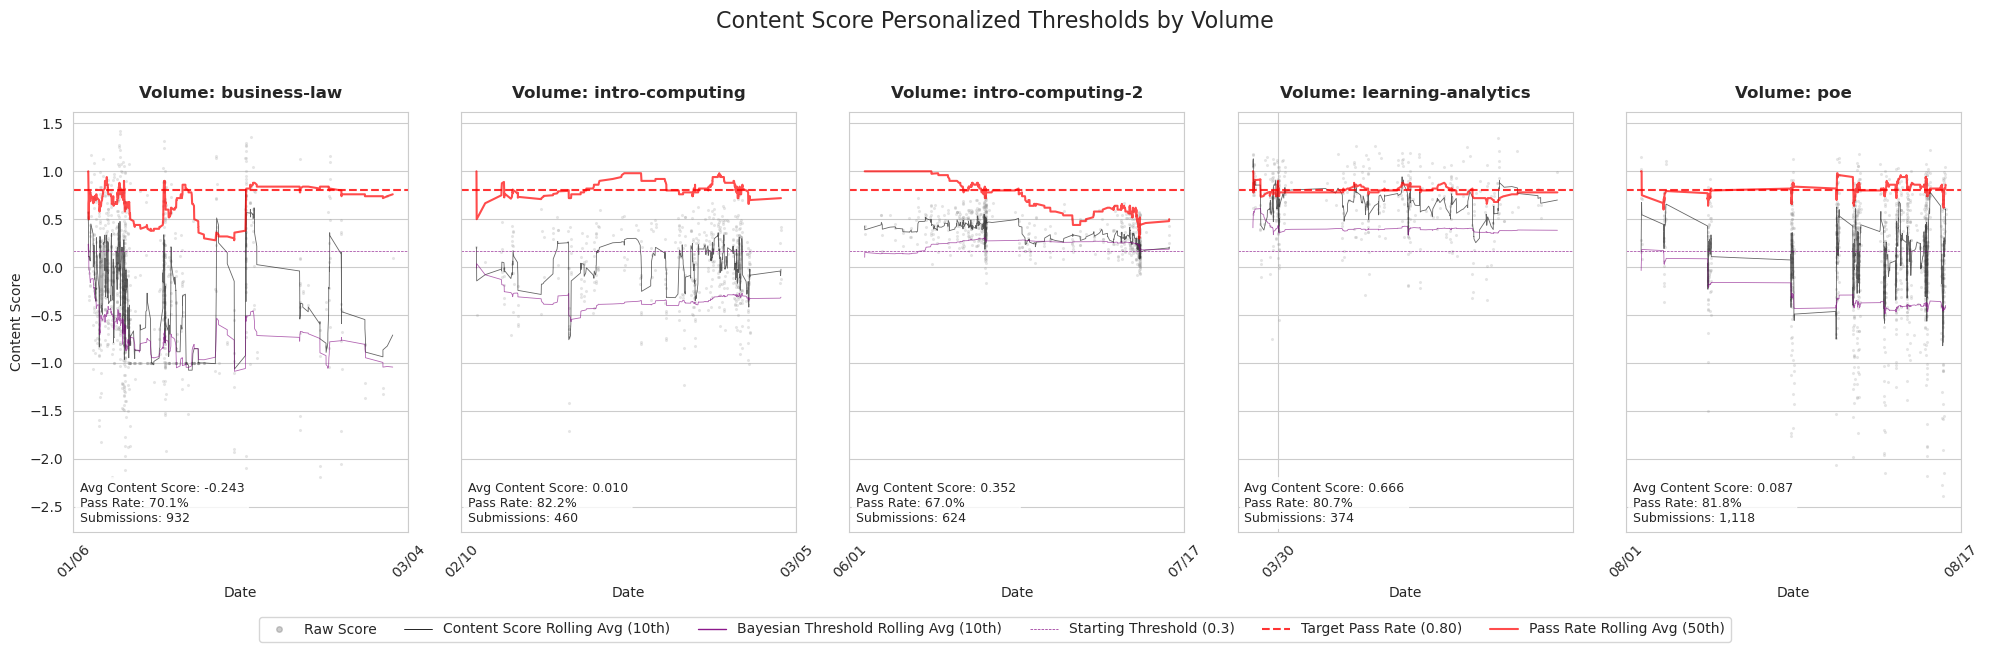

                mu_global: 0.8
                 k_global: 1
             alpha_global: 4
              beta_global: 1
                 k_volume: 30
        target_percentile: 0.2
   student_variance_scale: 1
                    max_k: None
            student_max_k: None
                max_alpha: None
                  k_decay: None
              alpha_decay: None
               beta_decay: None
          student_k_decay: None
      student_alpha_decay: None
       student_beta_decay: None


In [13]:
hp_dict = {
    'mu_global': 0.8,
    'k_global': 1,
    'alpha_global': 4,
    'beta_global': 1,
    'k_volume': 30,
    'target_percentile': 0.20,
    'student_variance_scale': 1,
    'max_k': None,
    'student_max_k': None,
    'max_alpha': None,
    'k_decay': None,
    'alpha_decay': None,
    'beta_decay': None,
    'student_k_decay': None,
    'student_alpha_decay': None,
    'student_beta_decay': None,
}

(df_w_thresholds, start_threshold, student_success, volume_updates, student_updates) = simulate_thresholds(
    df,
    hp_dict
)
plot_thresholds(df_w_thresholds, start_threshold, hp_dict["target_percentile"])

for k, v in hp_dict.items():
    print(f"{k:>25}: {v}")

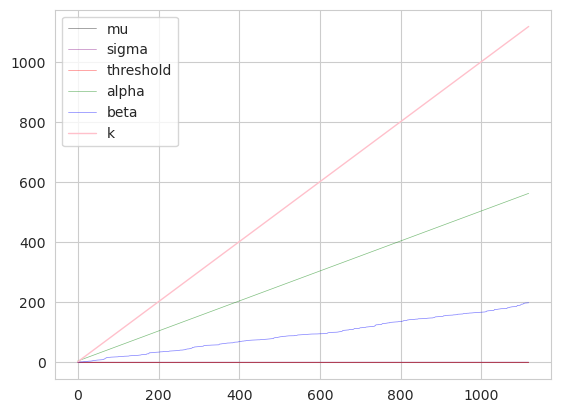

In [17]:
updates_array = np.array(volume_updates["poe"])
sns.lineplot(x=range(len(updates_array)), y=updates_array[:,0], color='black', label="mu", linewidth=0.5, alpha=0.5)
sns.lineplot(x=range(len(updates_array)), y=updates_array[:,1], color='purple', label="sigma", linewidth=0.5, alpha=0.5)
sns.lineplot(x=range(len(updates_array)), y=updates_array[:,2], color='red', label="threshold", linewidth=0.5, alpha=0.5)
sns.lineplot(x=range(len(updates_array)), y=updates_array[:,3], color='green', label="alpha", linewidth=0.5, alpha=0.5)
sns.lineplot(x=range(len(updates_array)), y=updates_array[:,4], color='blue', label="beta", linewidth=0.5, alpha=0.5)
sns.lineplot(x=range(len(updates_array)), y=updates_array[:,5], color='pink', label="k", linewidth=1, alpha=1)
plt.show();

#### No volume prior

In [63]:
volumes = {}
students = {}
student_success = defaultdict(list)
volume_updates = defaultdict(list)
student_updates = defaultdict(list)
submission_threshold = []

start_threshold = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=target_percentile).threshold

for row in df.itertuples():
    volume_name = row.Index[0]

    student_dist = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=target_percentile)

    if row.user_id in students:
        score_history = students[row.user_id]
        student_dist.update(score_history)
    else:
        students[row.user_id] = []

    threshold = student_dist.threshold
    submission_threshold.append(threshold)

    student_success[(volume_name, row.user_id)].append(row.content_score > threshold)

    # Append score to history
    student_updates[row.user_id].append((student_dist.mu, student_dist.sigma, student_dist.threshold, row.content_score))
    students[row.user_id].append(row.content_score)

df["bayesian_threshold"] = submission_threshold
submission_threshold = pd.DataFrame({"threshold": submission_threshold}, index=df.id)

### By Student

In [125]:
student_success_rates = {
    k[1]: {
        "volume": k[0],
        "mean_score": df.query('user_id == @k[1]')['content_score'].mean(),
        "pass_rate": np.mean(v),
        "num_summaries": len(v),
    } for k, v in student_success.items()}
pass_rates_by_student = pd.DataFrame.from_dict(student_success_rates, orient="index")
pass_rates_by_student.groupby("volume").agg(
    count=("mean_score", "count"),
    summaries=("num_summaries", "mean"),
    per_student_mean_pass_rate=("pass_rate", "mean"),
    per_student_std_pass_rate=("pass_rate", "std"),
).round(2)

,count,summaries,per_student_mean_pass_rate,per_student_std_pass_rate
volume,,,,
business-law,37,25.19,0.81,0.16
intro-computing,87,5.29,0.80,0.20
intro-computing-2,84,7.43,0.77,0.22
learning-analytics,90,4.16,0.82,0.29
poe,243,4.60,0.81,0.26


### By Volume

#### Learning Factors

In [67]:
volumes = {}
students = {}
student_success = defaultdict(list)
volume_updates = defaultdict(list)
student_updates = defaultdict(list)
submission_threshold = []
lf_up = 0.01
lf_down = 0.03

volume_threshold = .4

def update_threshold(threshold, scores):
    for score in scores:
        if score > threshold:
            threshold += lf_up
        elif score < threshold:
            threshold -= lf_down
    return threshold


for row in df.itertuples():
    volume_name = row.Index[0]    

    if row.user_id in students:
        score_history = students[row.user_id]
        threshold = update_threshold(volume_threshold, score_history)
    else:
        students[row.user_id] = []
        threshold = volume_threshold

    volume_threshold = update_threshold(volume_threshold, [row.content_score])
    volume_updates[volume_name].append((None, None, volume_threshold))

    submission_threshold.append(threshold)

    student_success[(volume_name, row.user_id)].append(row.content_score > threshold)

    # Append score to history
    student_updates[row.user_id].append((None, None, threshold, row.content_score))
    students[row.user_id].append(row.content_score)

df["simple_threshold"] = submission_threshold
submission_threshold = pd.DataFrame({"threshold": submission_threshold}, index=df.id)

#### Single Axis

,Volume,20th Percentile,Bayesian Personalized,20th Percentile (Skip 100)
0,business-law,0.71,0.59,0.71
1,intro-computing,0.78,0.60,0.76
2,intro-computing-2,0.78,0.86,0.78
3,learning-analytics,0.77,0.89,0.80
4,poe,0.79,0.67,0.80


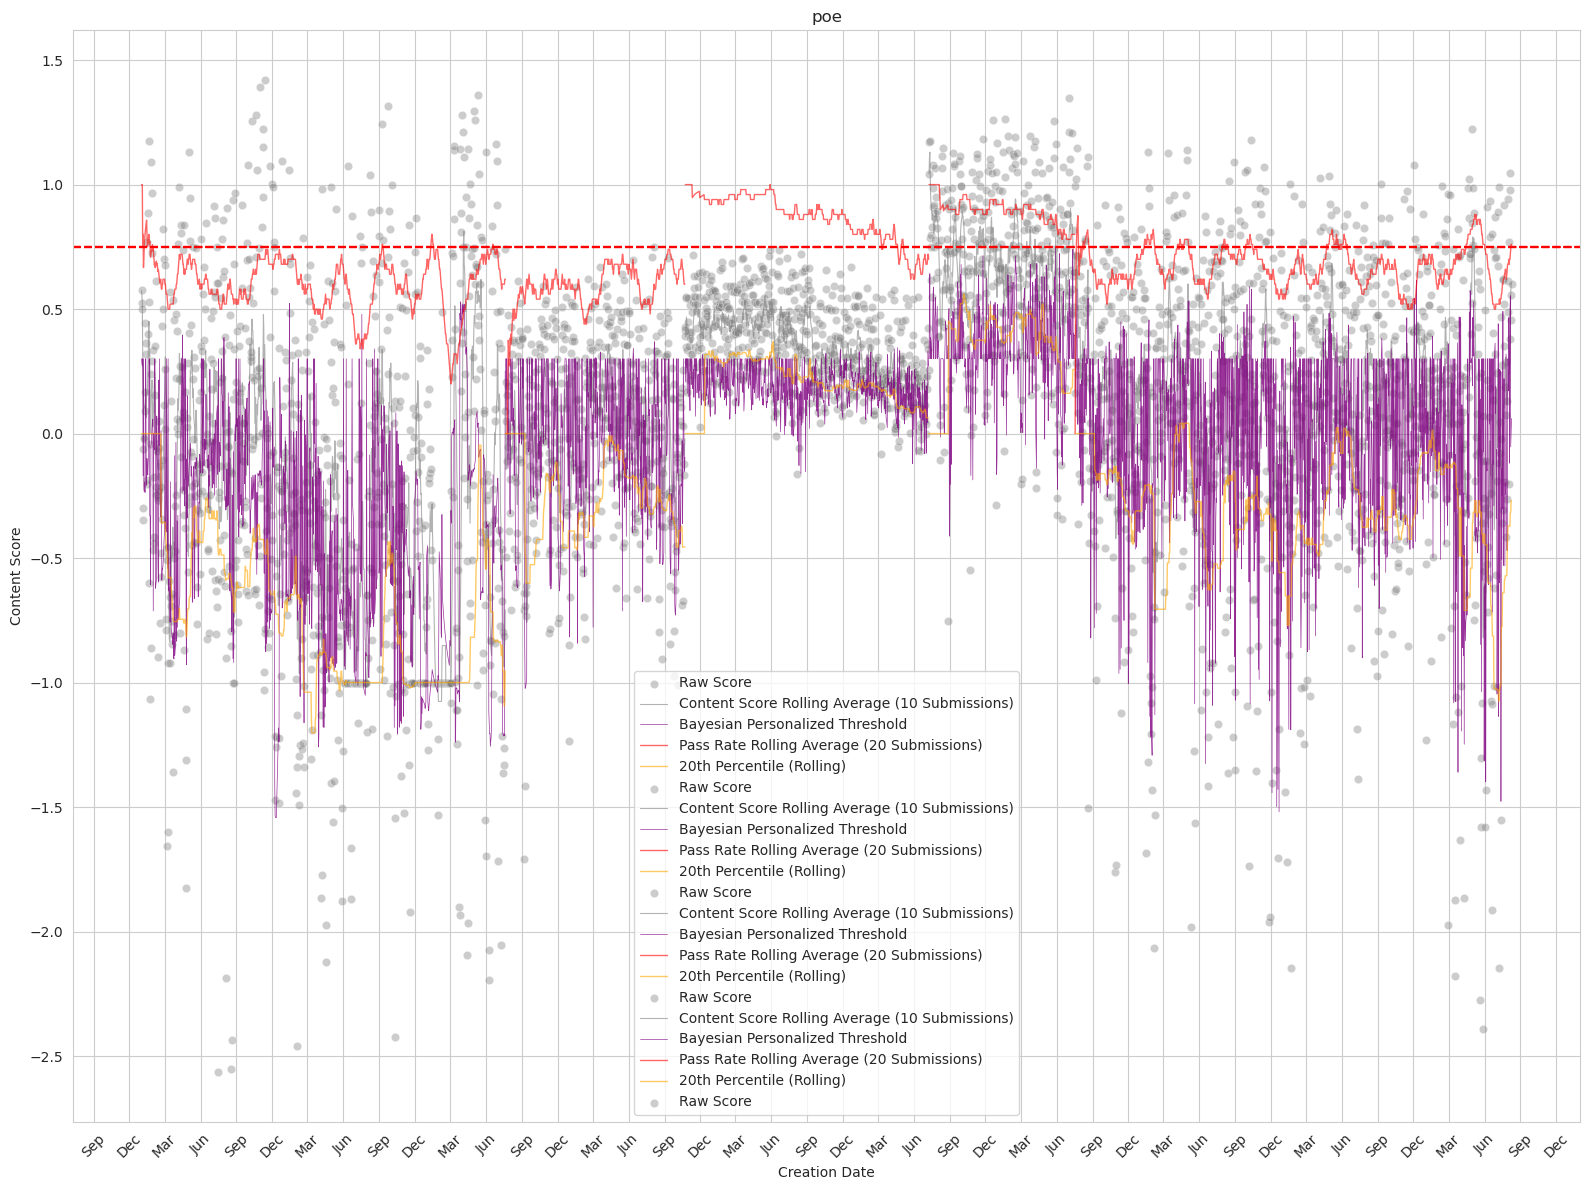

In [22]:
df = df.sort_values('created_at')

sns.set_style("whitegrid")
fig, axs = plt.subplots(4, figsize=(16, 12), sharex=True)

pass_rates = []

for ax, (name, group) in zip(axs, df.reset_index(0, names="volume").groupby("volume")):
    group = group.sort_values("created_at")

    # Create the main line plot
    sns.scatterplot(ax=ax, data=group, x='created_at', y='content_score', 
                 label='Raw Score', alpha=0.4, color='gray')
    
    # Calculate and plot rolling average (10 submissions)
    rolling_avg = group['content_score'].rolling(window=10, min_periods=1).mean()
    sns.lineplot(ax=ax, x=group["created_at"], y=rolling_avg, 
                 label='Content Score Rolling Average (10 Submissions)', legend=False,
                 color='gray', linewidth=.8, alpha=0.6)
    
    # Draw Simple Threshold
    # sns.lineplot(ax=ax, data=group, x='created_at', y='simple_threshold', 
    #              label='Simple Personalized Threshold', legend=False,
    #              color='red', linewidth=0.5, alpha=0.8)
    
    # Draw Bayesian Threshold
    sns.lineplot(ax=ax, data=group, x='created_at', y='bayesian_threshold', 
                 label='Bayesian Personalized Threshold', legend=False,
                 color='purple', linewidth=0.5, alpha=0.8)

    # # Draw Fixed Variance Bayesian Threshold
    # sns.lineplot(ax=ax, data=group, x='created_at', y='bayesian_threshold', 
    #              label='Fixed Var Personalized Threshold', legend=False,
    #              color='green', linewidth=1, alpha=0.6)

    # Draw target pass rate
    target_pass_rate = 1 - target_percentile
    plt.axhline(y=target_pass_rate, color="red", linestyle='--')

    # Draw Pass Rate Rolling Window
    pass_rate_rolling_20th = (group["content_score"] > group["bayesian_threshold"]).astype(int).rolling(window=50, min_periods=1).mean()
    sns.lineplot(ax=ax, x=group["created_at"], y=pass_rate_rolling_20th, 
                 label='Pass Rate Rolling Average (20 Submissions)', legend=False,
                 color='red', linewidth=1, alpha=0.6)

    # Draw Volume Prior
    updates_array = np.array(volume_updates[name])

    # Simple Volume Threshold
    # sns.lineplot(ax=ax, x=group['created_at'], y=updates_array[:,2], 
    #              label='Simple Volume Threshold', legend=False,
    #              color='purple', linewidth=1, alpha=0.6)
    
    # Bayesian Volume Prior
    # sns.lineplot(ax=ax, x=group['created_at'], y=updates_array[:,2], 
    #              label='Bayesian Volume Prior Threshold', legend=False,
    #              color='purple', linewidth=1, alpha=0.6)
    
    # Draw Observed 20th Percentile Threshold
    window_size = 50
    rolling_20th = group["content_score"].rolling(window=window_size, min_periods=1).quantile(0.2)


    # Skip first 100 scores for mean calculations
    group_subset = group.iloc[100:] if len(group) > 100 else group
    
    pass_rates.append({
        "Volume": name,
        "20th Percentile": (group["content_score"] > rolling_20th).astype(int).mean(),
        # "Simple Personalized": (group["content_score"] > group["simple_threshold"]).astype(int).mean(),
        # "Simple Volume Only": (group["content_score"] > updates_array[:,2]).astype(int).mean(),
        "Bayesian Personalized": (group["content_score"] > group["bayesian_threshold"]).astype(int).mean(),
        # "Bayesian Volume Prior Only": (group["content_score"] > updates_array[:,2]).astype(int).mean(),
        # "Fixed Var Threshold": (group["content_score"] > group["fixed_var_threshold"]).astype(int).mean(),
        "20th Percentile (Skip 100)": (group_subset["content_score"] > rolling_20th[100:] if len(group) > 100 else rolling_20th).astype(int).mean(),
        # "Bayesian Personalized (Skip 100)": (group_subset["content_score"] > group_subset["bayesian_threshold"]).astype(int).mean(),
        # "Bayesian Volume Prior Only (Skip 100)": (group_subset["content_score"] > updates_array[100:,2] if len(group) > 100 else updates_array[:,2]).astype(int).mean()
    })

    # Manually set the threshold for the first window_size samples
    # Since we don't have enough data to calculate a fair rolling average
    rolling_20th.iloc[:window_size] = 0.0
    sns.lineplot(
        ax=ax, data=group, x='created_at', y=rolling_20th,
        label='20th Percentile (Rolling)', legend=False,
        color='orange', linewidth=1, alpha=0.6
    )

    ax.title.set_text(name)
    
    # Format x-axis to show only month-year
    plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%b'))
    plt.gca().xaxis.set_major_locator(mpl.dates.MonthLocator(interval=3))
    
    # Rotate x-axis labels
    plt.xticks(rotation=45)

# Show Pass Rates
display(pd.DataFrame(pass_rates).round(2))

# Add legend
labels_handles = {}
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        labels_handles[label] = handle

fig.legend(labels_handles.values(), labels_handles.keys(), loc='upper right', bbox_transform=fig.transFigure, ncol=1)

# plt.title('Content Score Thresholds', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')
plt.tight_layout()
    
plt.show();

### Check how pass/fails differ with Bayesian updating

In [127]:
def get_percent(ser, name="Default"):
    display(ser.value_counts(normalize=True).rename(name).mul(100).round(1).astype(str) + '%')

print("All Summaries\n")
get_percent(df.content_score > 0)
print()
get_percent(df["content_score"] > submission_threshold.threshold.values, name="Bayes")

print("First Submissions\n")
first_submissions_w_thresholds = pd.merge(first_submissions, submission_threshold.threshold, left_on="id", right_on="id")
get_percent(first_submissions_w_thresholds["content_score"] > 0)
print()
get_percent(first_submissions_w_thresholds["content_score"] > first_submissions_w_thresholds.threshold, name="Bayes")

All Summaries



content_score
True     57.1%
False    42.9%
Name: Default, dtype: object

content_score
True     75.1%
False    24.9%
Name: Bayes, dtype: object

First Submissions



content_score
True     61.7%
False    38.3%
Name: Default, dtype: object

True     75.8%
False    24.2%
Name: Bayes, dtype: object

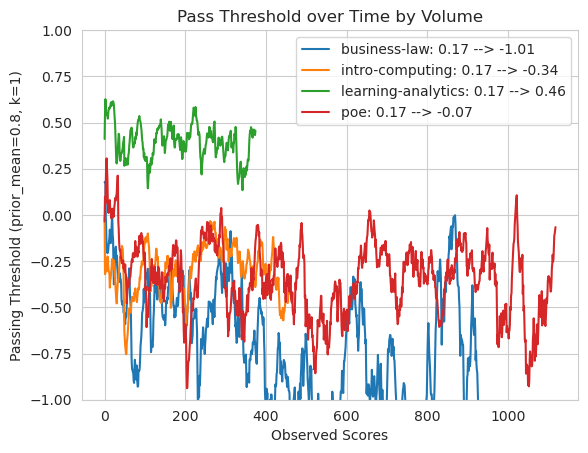

In [36]:
fig, ax = plt.subplots()
ax.set_ylim(-1, 1)

for volume_name, updates in volume_updates.items():
    arr = np.array(updates)
    means = arr[:,0]
    sigmas = arr[:,1]
    thresholds = arr[:,2]
    x = np.linspace(0, len(updates), len(updates))
    end_threshold = volumes[volume_name].threshold
    ax.plot(x, thresholds, label=f"{volume_name}: {start_threshold:.2f} --> {end_threshold:.2f}")    
    # ax.fill_between(x, means - sigmas, means + sigmas, alpha=0.05)
ax.set_title("Pass Threshold over Time by Volume")
ax.set_ylabel(f"Passing Threshold (prior_mean={mu_global}, k={k_global})")
ax.set_xlabel("Observed Scores")
ax.legend();